# Random forest on pleasant days classification

## Table of contents

### [1. Libraries import and Data preparation](#1)

### [2. Create and Run the Random Forest Model](#2)
#### [2.1 Random forest on 10 years with all weather stations ](#2.1)
#### [2.2 Random forest on the top 3 important weather stations](#2.2)



## 1. Libraries import and Data preparation
<div id='1'></div>

In [17]:
import pandas as pd
import numpy as np
import seaborn as sns
import os
import operator
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn import datasets  
from sklearn.ensemble import RandomForestClassifier
from numpy import argmax
from sklearn import metrics  
from sklearn.tree import plot_tree
from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


##to ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Creating paths to the data folder of the project and to the folder for saving the charts
path_data = r"C:\Users\dacol\Documents\Data_Project_careerfoundry\ClimateWins_ML\02 Data"

# Importing the cleaned dataset with the weather observations
df_weather = pd.read_pickle(os.path.join(path_data,'Prepared Data','Cleaned_ML_ready.pkl'))

# Importing the rated dataframe for pleasant days
df_rate = pd.read_csv(os.path.join(path_data,'Original Data','Dataset-Answers-Weather_Prediction_Pleasant_Weather.csv'), sep =',')

In [19]:
print(df_weather.shape)
print(df_rate.shape)

(22950, 135)
(22950, 16)


In [21]:
df_weather.head()

,BASEL_cloud_cover,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_sunshine,BASEL_temp_mean,BASEL_temp_min,BASEL_temp_max,BELGRADE_cloud_cover,...,STOCKHOLM_humidity,VALENTIA_cloud_cover,VALENTIA_humidity,VALENTIA_pressure,VALENTIA_global_radiation,VALENTIA_precipitation,VALENTIA_sunshine,VALENTIA_temp_mean,VALENTIA_temp_min,VALENTIA_temp_max
0,7,0.85,1.018,0.32,0.09,0.7,6.5,0.8,10.9,1,...,0.98,5,0.88,1.0003,0.45,0.34,4.7,8.5,6.0,10.9
1,6,0.84,1.018,0.36,1.05,1.1,6.1,3.3,10.1,6,...,0.62,7,0.91,1.0007,0.25,0.84,0.7,8.9,5.6,12.1
2,8,0.90,1.018,0.18,0.30,0.0,8.5,5.1,9.9,6,...,0.69,7,0.91,1.0096,0.17,0.08,0.1,10.5,8.1,12.9
3,3,0.92,1.018,0.58,0.00,4.1,6.3,3.8,10.6,8,...,0.98,7,0.86,1.0184,0.13,0.98,0.0,7.4,7.3,10.6
4,6,0.95,1.018,0.65,0.14,5.4,3.0,-0.7,6.0,8,...,0.96,3,0.80,1.0328,0.46,0.00,5.7,5.7,3.0,8.4


In [27]:
df_rate.head()

,DATE,BASEL_pleasant_weather,BELGRADE_pleasant_weather,BUDAPEST_pleasant_weather,DEBILT_pleasant_weather,DUSSELDORF_pleasant_weather,HEATHROW_pleasant_weather,KASSEL_pleasant_weather,LJUBLJANA_pleasant_weather,MAASTRICHT_pleasant_weather,MADRID_pleasant_weather,MUNCHENB_pleasant_weather,OSLO_pleasant_weather,SONNBLICK_pleasant_weather,STOCKHOLM_pleasant_weather,VALENTIA_pleasant_weather
0,19600101,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,19600102,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,19600103,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,19600104,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,19600105,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [29]:
# Select 10 consecutive years from df_rate
years = df_rate['DATE'].apply(lambda x: str(x)[:4]).unique()[:10]
df_rate_10_years = df_rate[df_rate['DATE'].apply(lambda x: str(x)[:4]).isin(years)]

# Filter data for each weather station individually
stations = [col.split('_')[0] for col in df_weather.columns if '_' in col]
unique_stations = list(set(stations))


## 2. Create and Run the Random Forest Model:
<div id='2'></div>

### 2.1 Random forest on 10 years with all weather stations
<div id='2.1'></div>

In [33]:
# Define the shape of the data
X = df_weather.values

# Extract the target variable 'pleasant_weather' for each station
# Ensure the target variable matches the shape of the features
y = df_rate_10_years.iloc[:, 1:].values.flatten()

# Filter the target variable to match the number of samples in X
y = y[:X.shape[0]]

# Train the random forest model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Predict and record accuracy
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy}")


Model Accuracy: 0.807843137254902


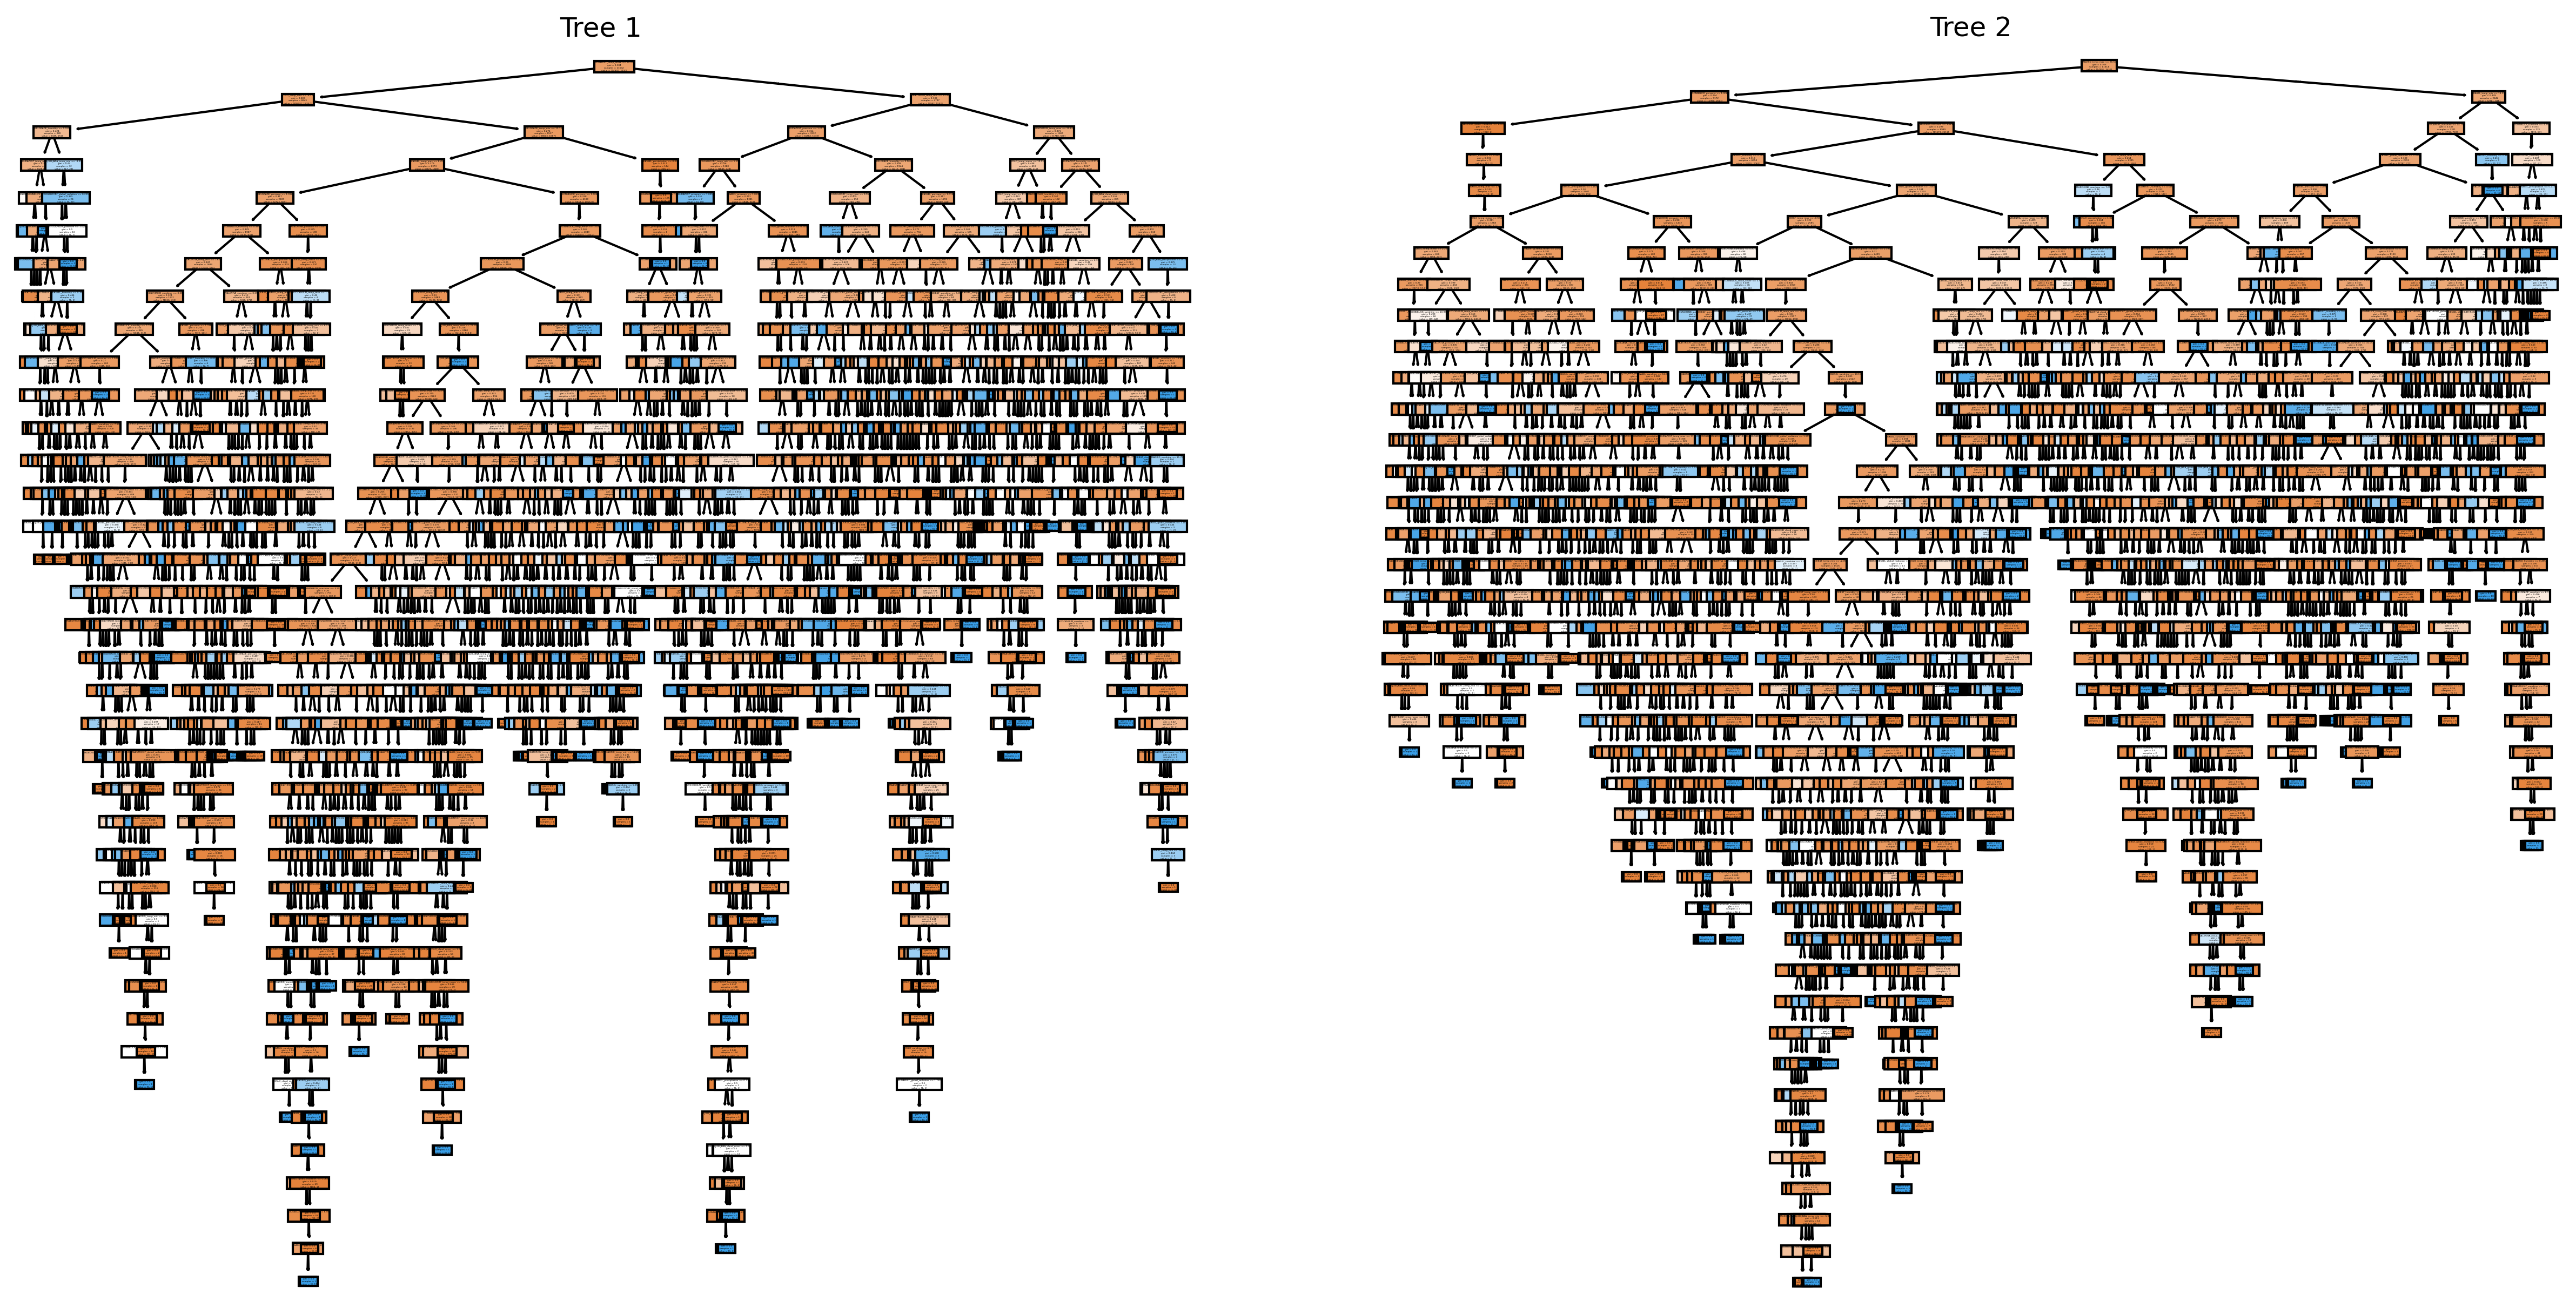

In [35]:
# Plot two different trees from the random forest model
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 10), dpi=300)
for index in range(2):
    plot_tree(clf.estimators_[index], ax=axes[index], feature_names=df_weather.columns, filled=True)
    axes[index].set_title(f"Tree {index + 1}")

# Save and show the plots
plt.savefig('random_forest_trees.png')
plt.show()


In [36]:
# Extract feature importances
importances = clf.feature_importances_

# Reshape the list to (-1, 15, 9)
importances_reshaped = importances.reshape(-1, 15, 9)

# Collapse the shape into one observation for each weather station
importances_collapsed = np.sum(importances_reshaped[0], axis=1)


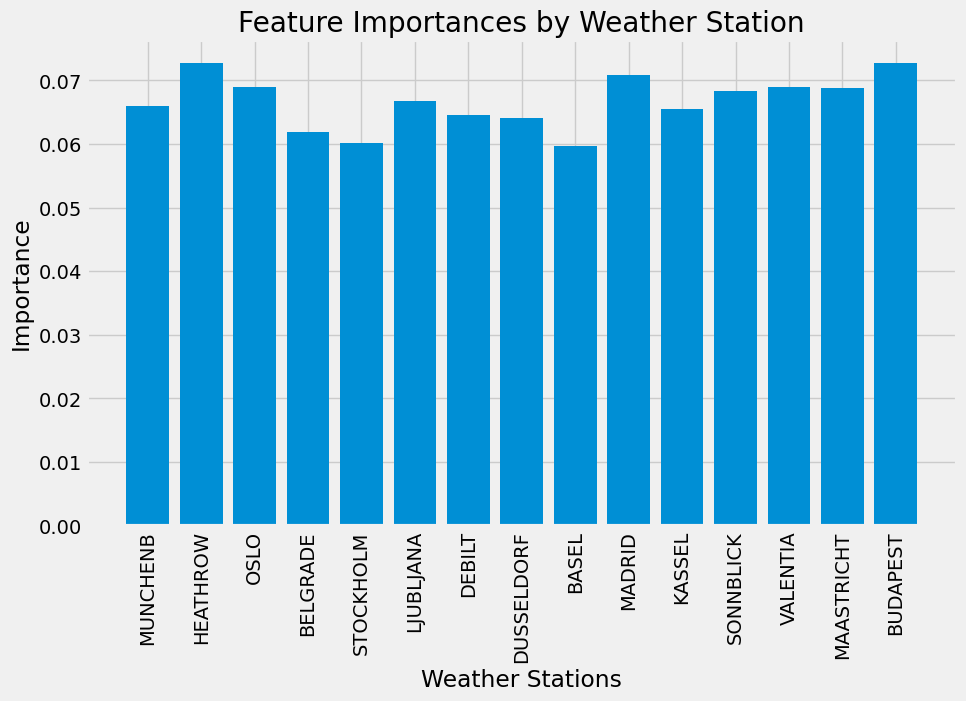

In [52]:
# Plot a bar chart of the importances against a list of the weather stations
plt.style.use('fivethirtyeight')
plt.figure(figsize=(10, 6))
plt.bar(unique_stations, importances_collapsed)
plt.xlabel('Weather Stations')
plt.ylabel('Importance')
plt.title('Feature Importances by Weather Station')
plt.xticks(rotation=90)
plt.savefig('feature_importances.png')
plt.show()


### 2.2 Random forest on the top 3 important weather stations
<div id='2.2'></div>

In [38]:
# Identify top three stations
top_stations = np.argsort(importances_collapsed)[-3:]

# Create subsets for the top three stations
subsets = {}
for station in top_stations:
    station_name = unique_stations[station]
    subsets[station_name] = df_weather.filter(like=station_name)


Model Accuracy for MADRID: 1.0


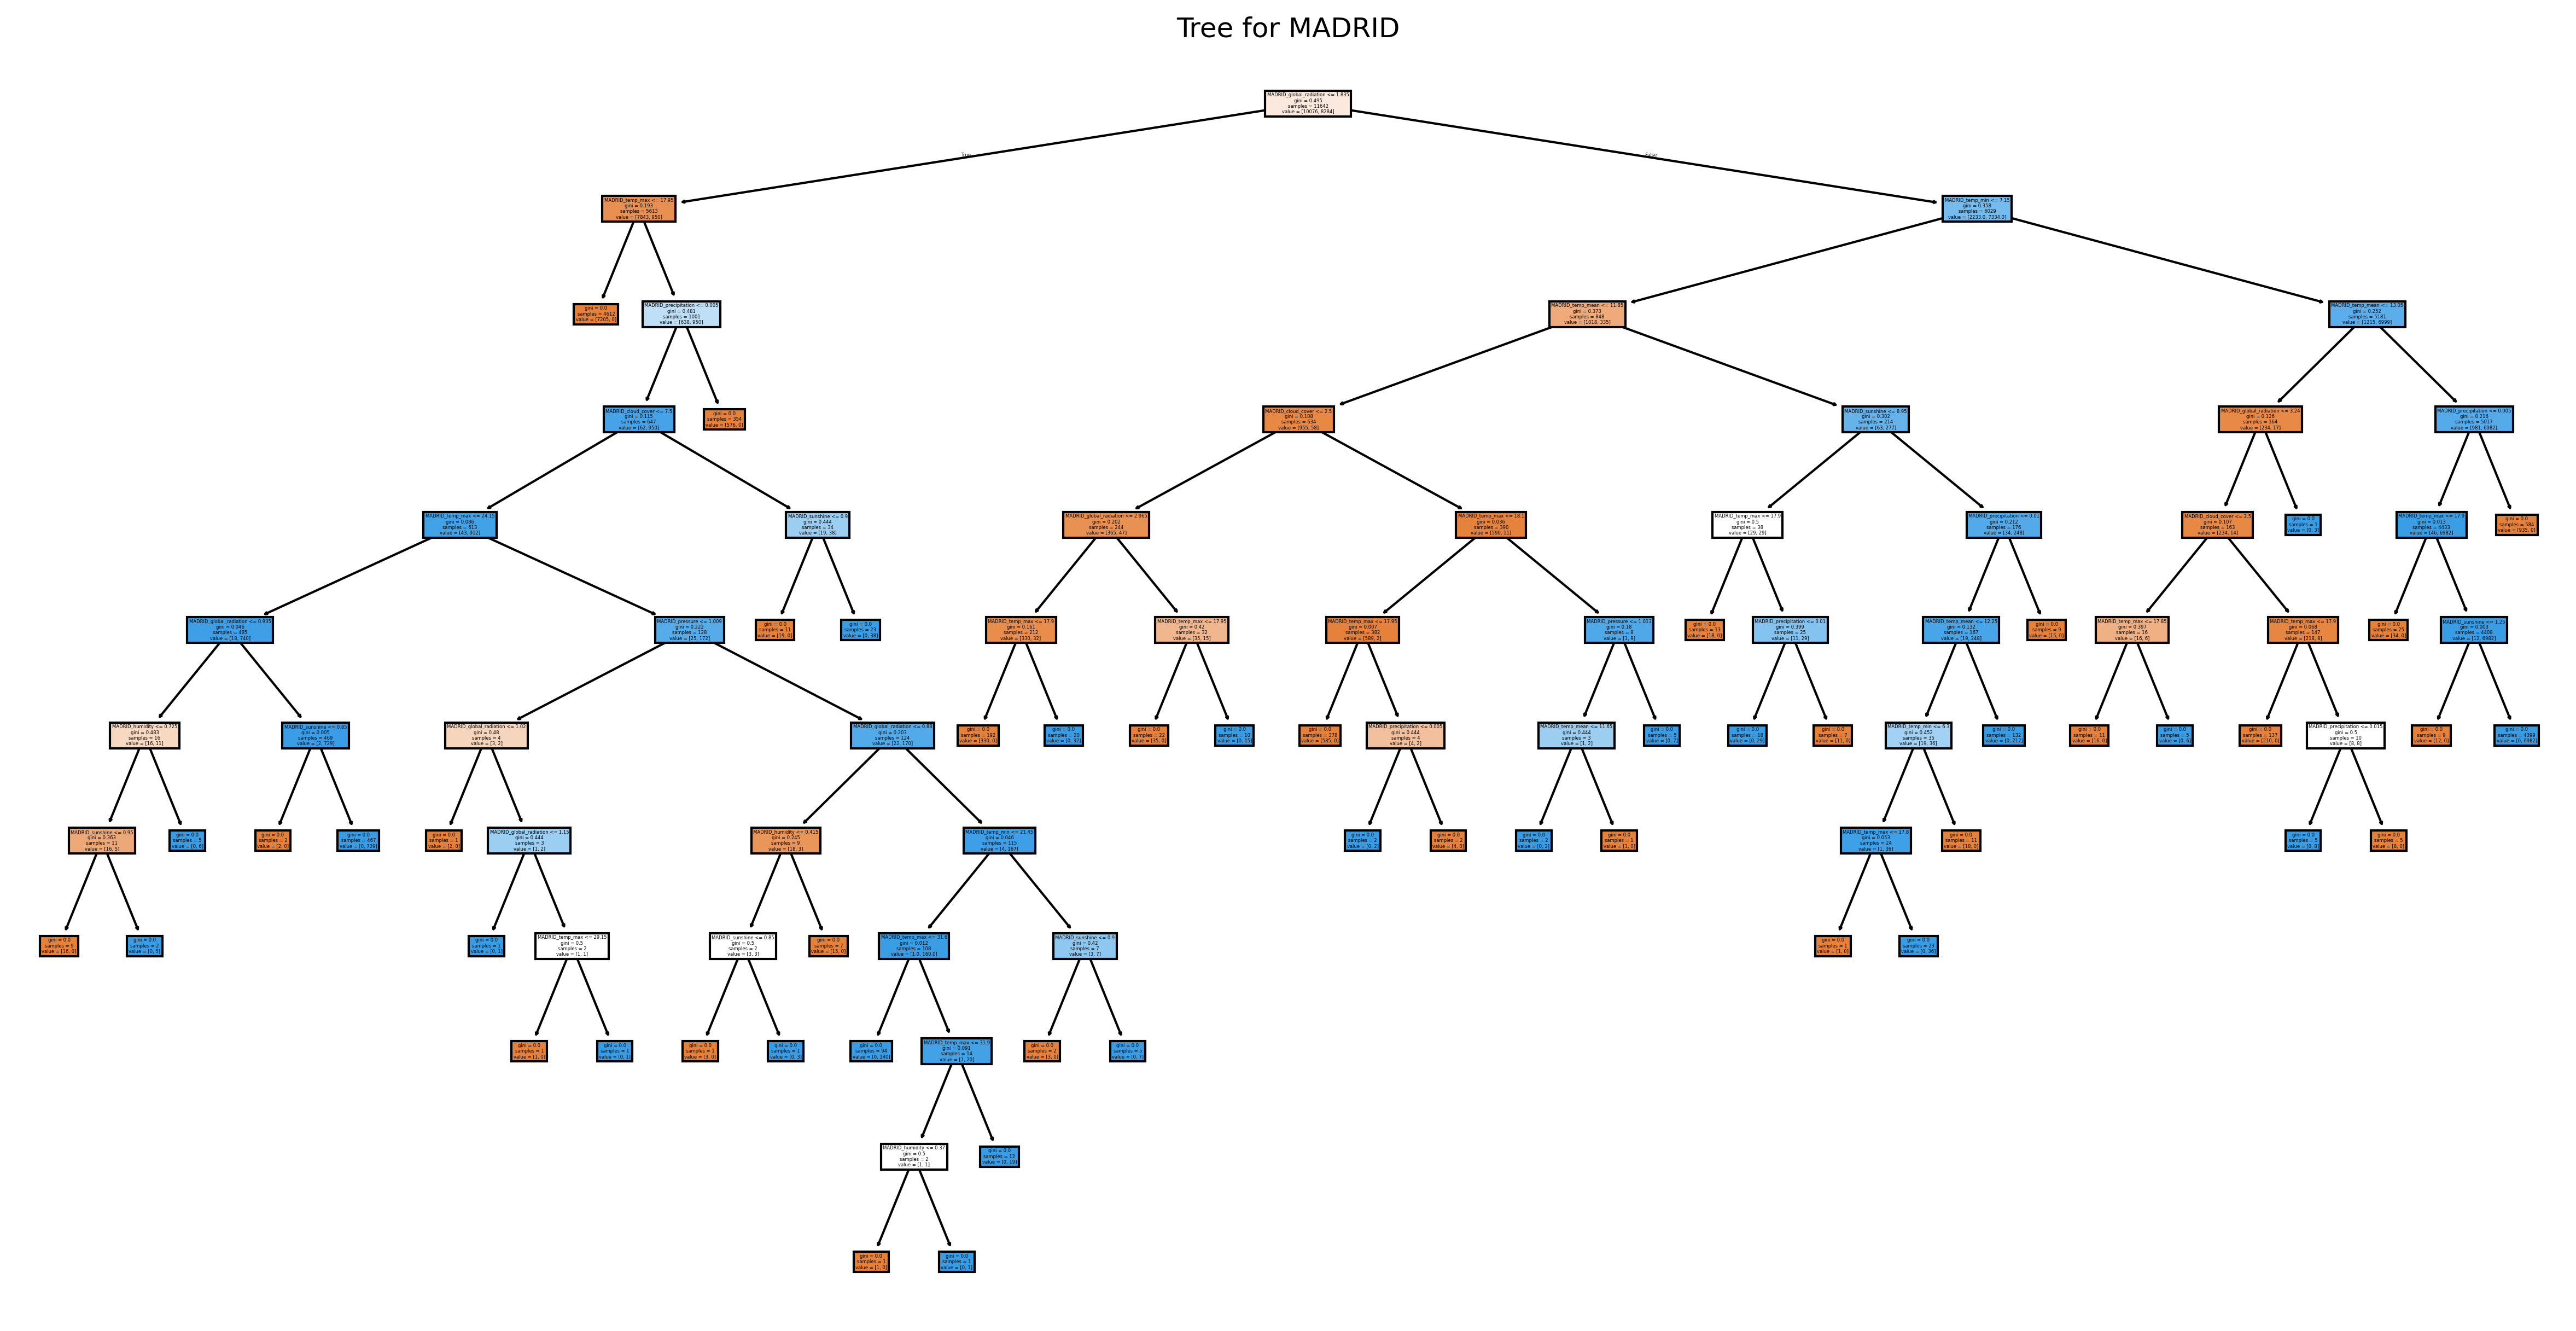

Model Accuracy for BUDAPEST: 1.0


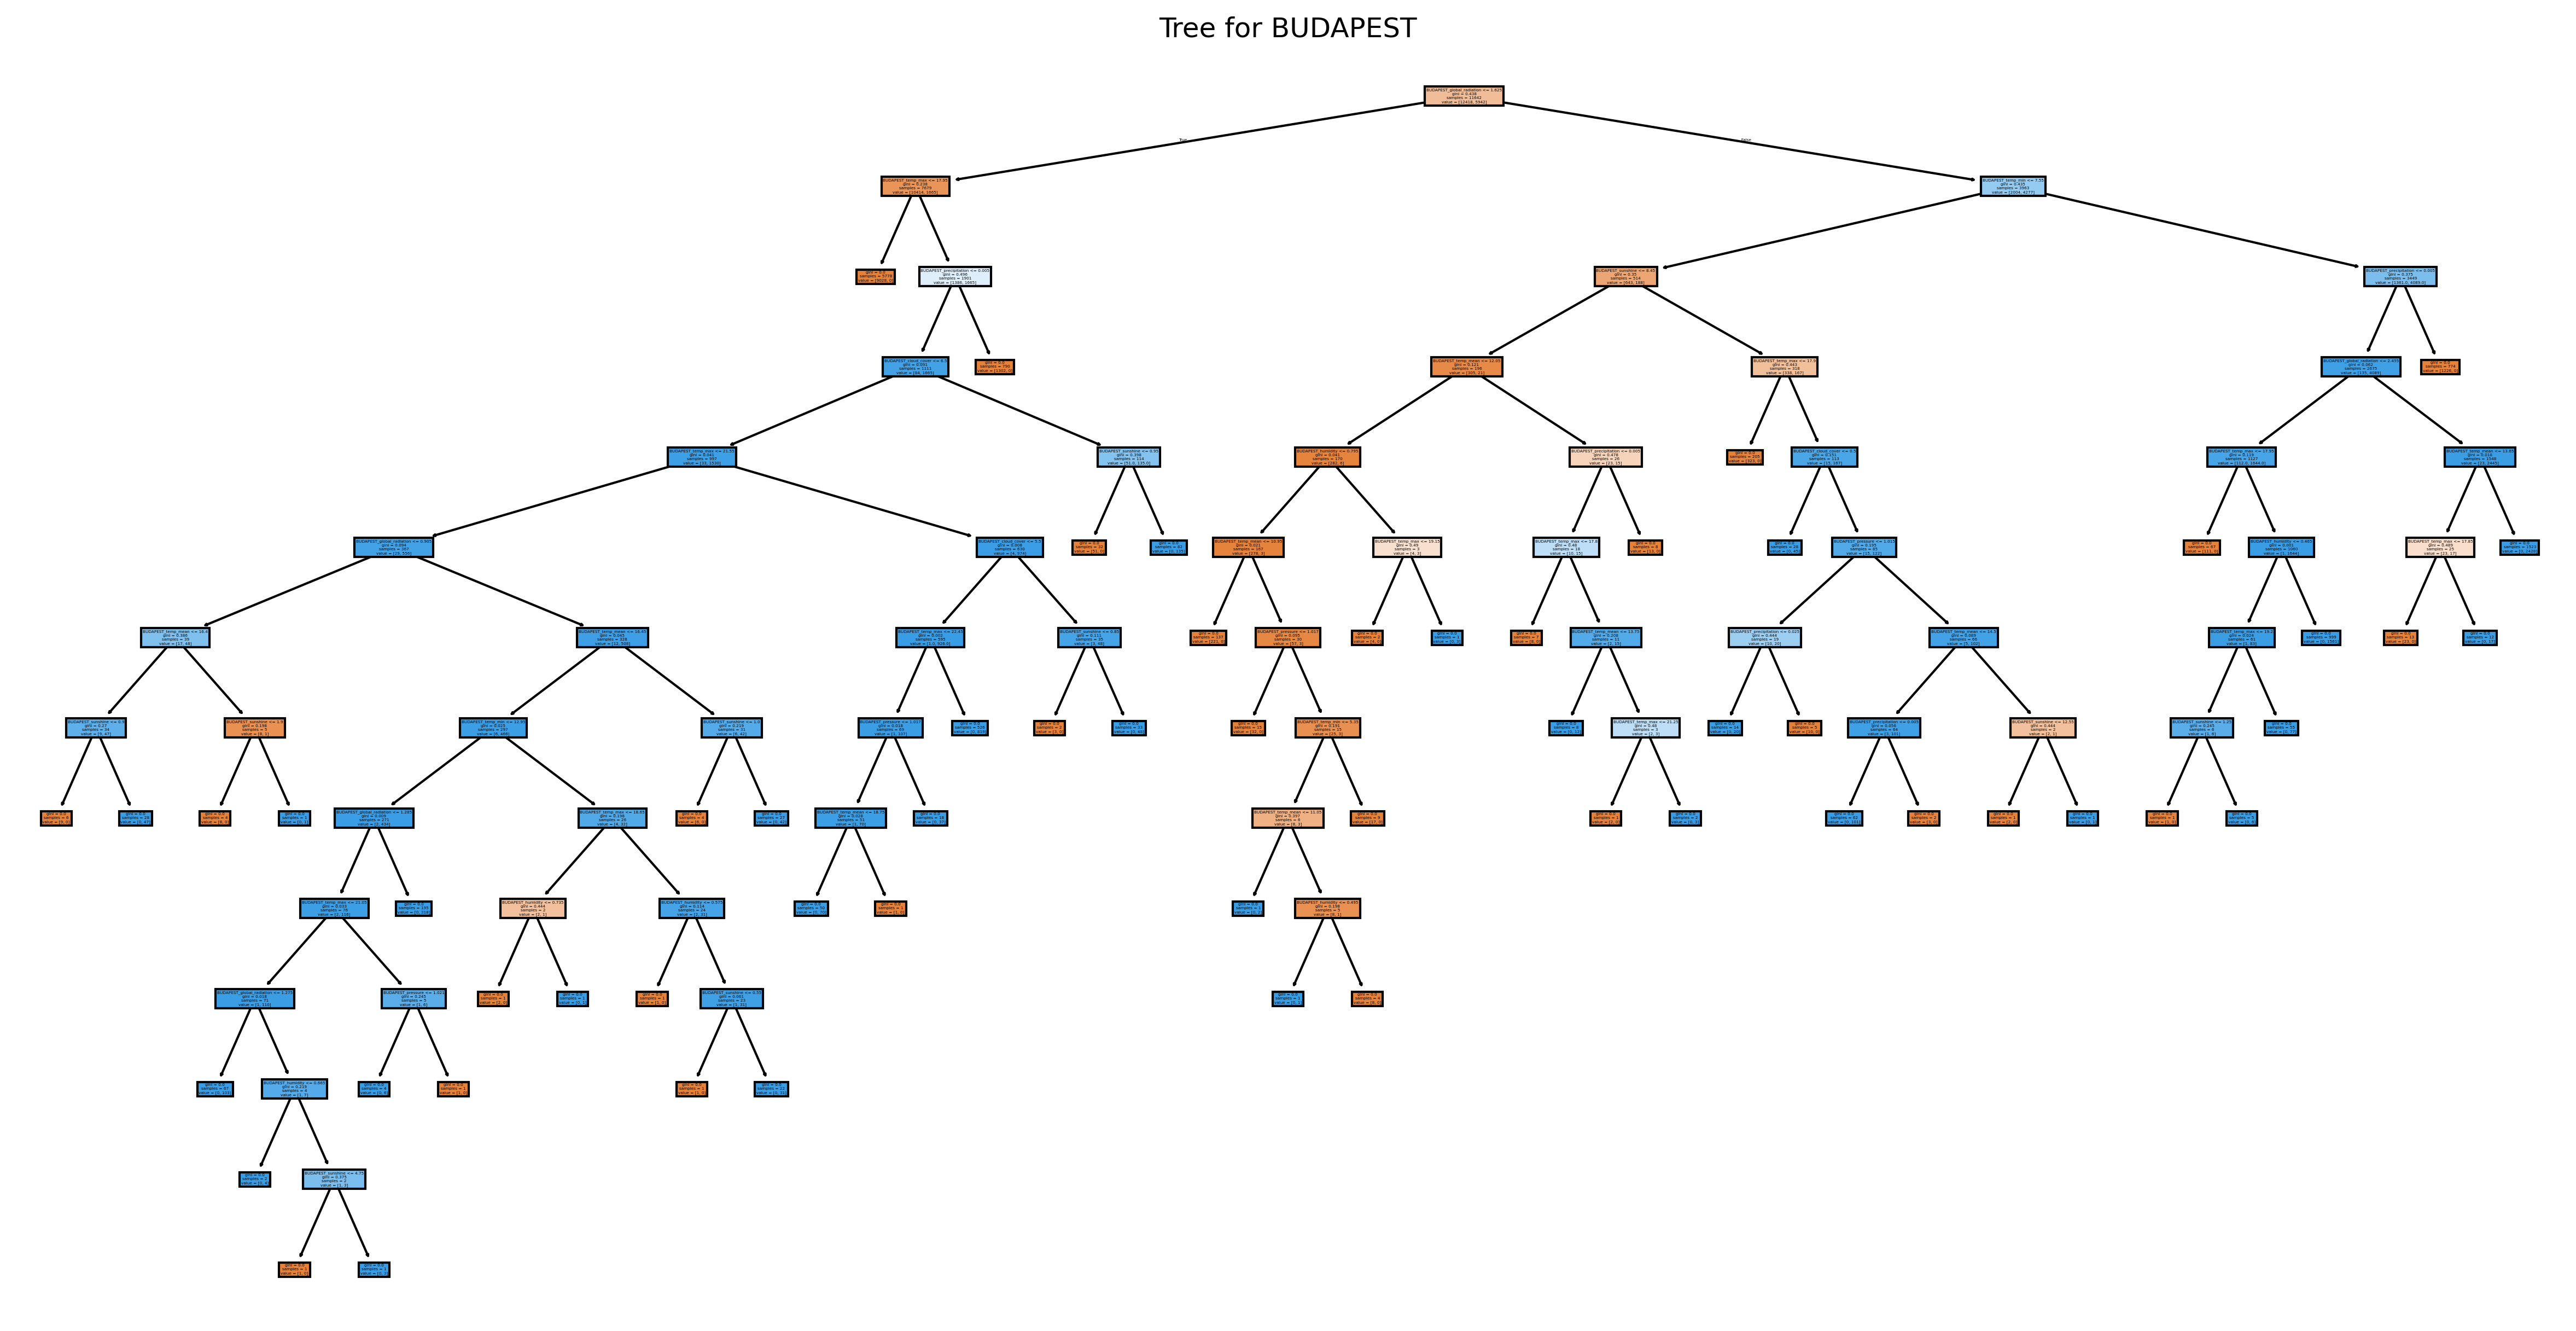

Model Accuracy for HEATHROW: 1.0


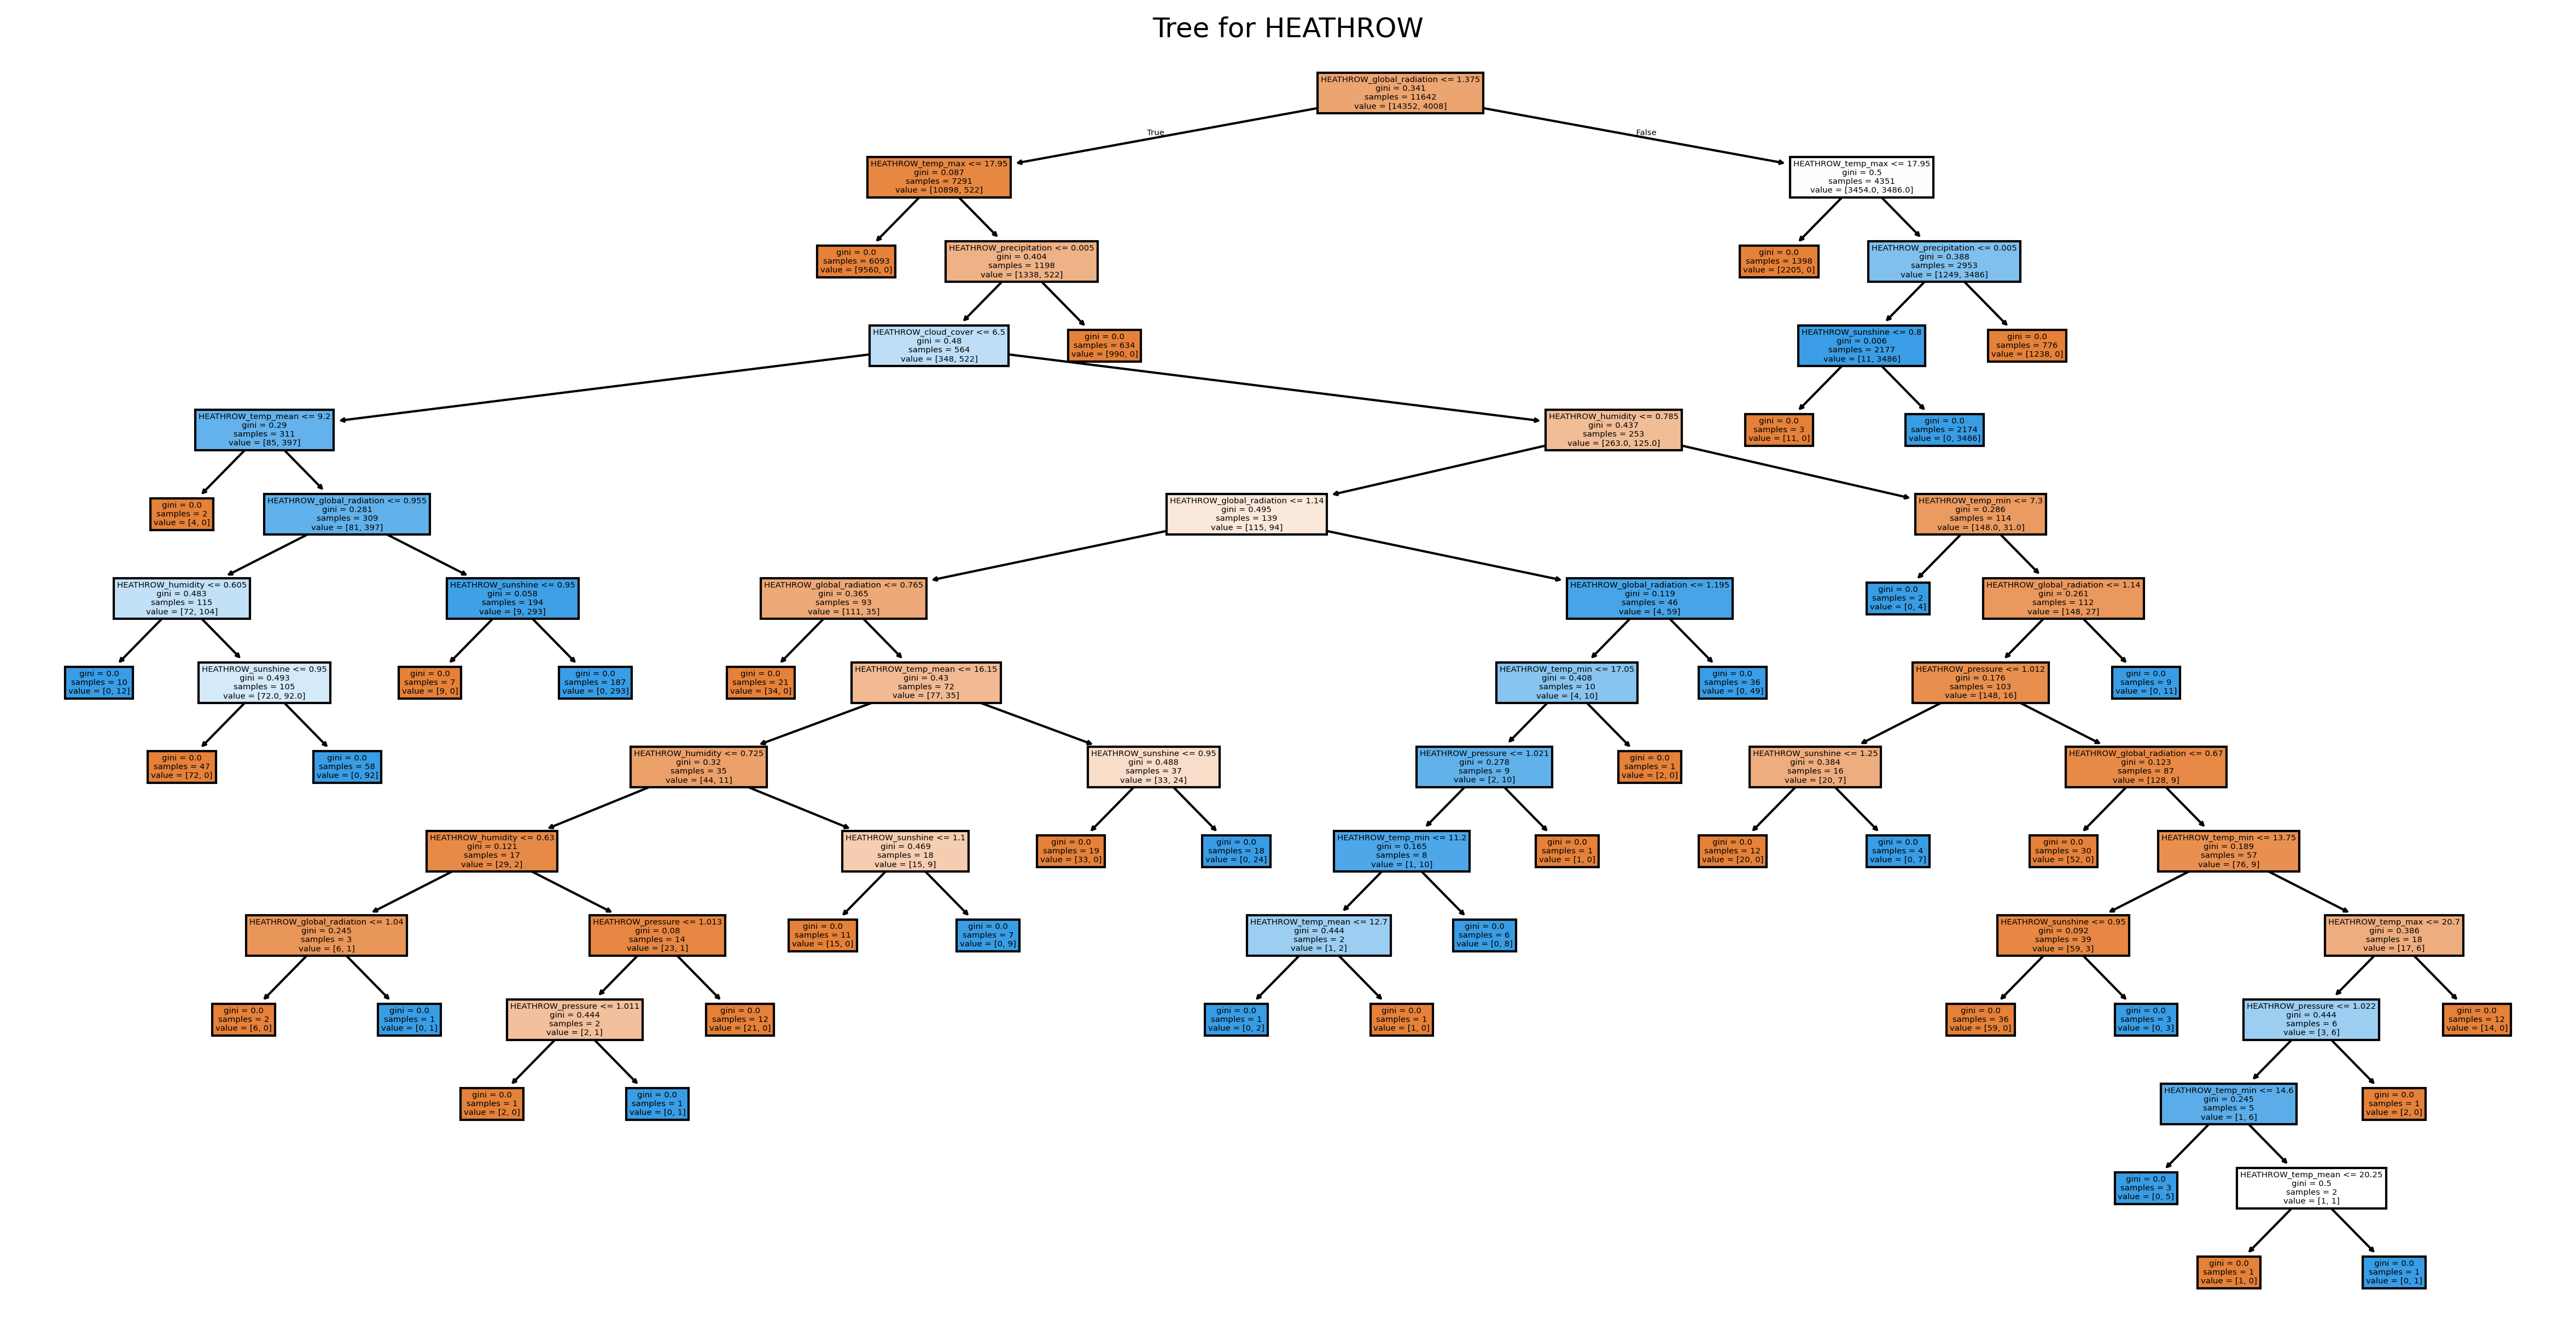

In [46]:
# Train random forest model for each top station
for station_name, subset in subsets.items():
    # Ensure the target variable matches the shape of the features for the entire period
    y_station = df_rate[f"{station_name}_pleasant_weather"].values

    X_station = subset.values

    # Check if the shapes of X_station and y_station are consistent
    if X_station.shape[0] != y_station.shape[0]:
        print(f"Shape mismatch for {station_name}: X_station shape = {X_station.shape}, y_station shape = {y_station.shape}")
        continue

    X_train, X_test, y_train, y_test = train_test_split(X_station, y_station, test_size=0.2, random_state=42)
    clf_station = RandomForestClassifier(n_estimators=100, random_state=42)
    clf_station.fit(X_train, y_train)

    # Predict and record accuracy
    y_pred_station = clf_station.predict(X_test)
    accuracy_station = accuracy_score(y_test, y_pred_station)
    print(f"Model Accuracy for {station_name}: {accuracy_station}")

    # Plot one of the trees
    plt.figure(figsize=(20, 10), dpi=300)
    plot_tree(clf_station.estimators_[0], feature_names=subset.columns, filled=True)
    plt.title(f"Tree for {station_name}")
    plt.savefig(f'tree_{station_name}.png')
    plt.show()


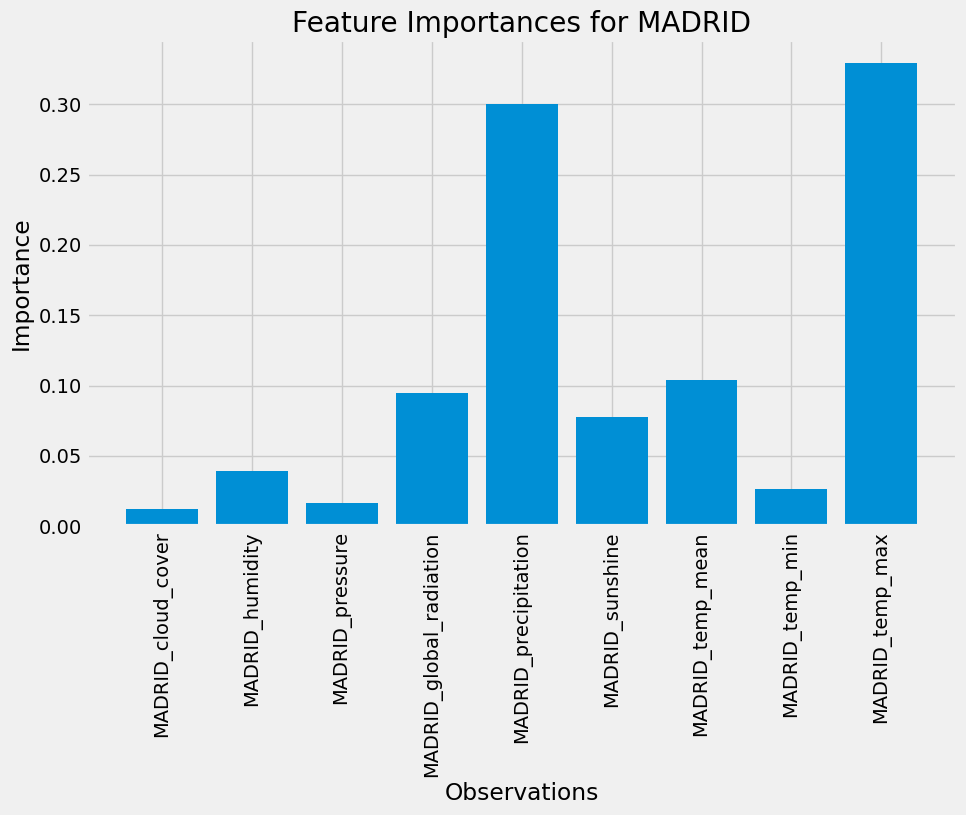

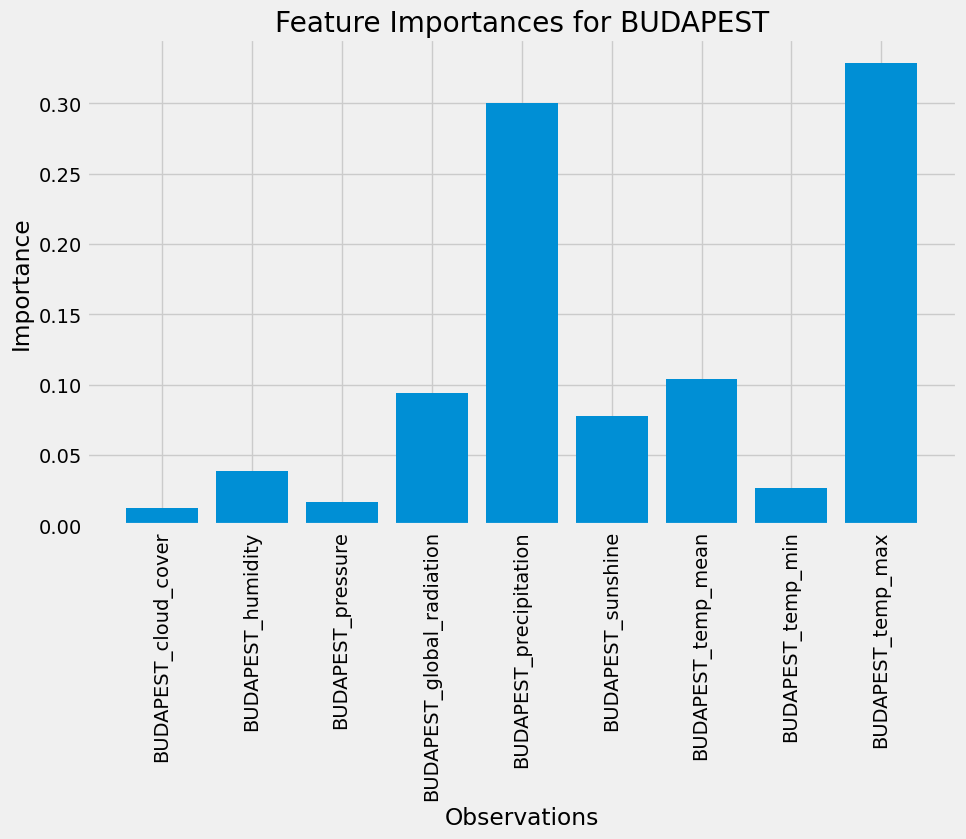

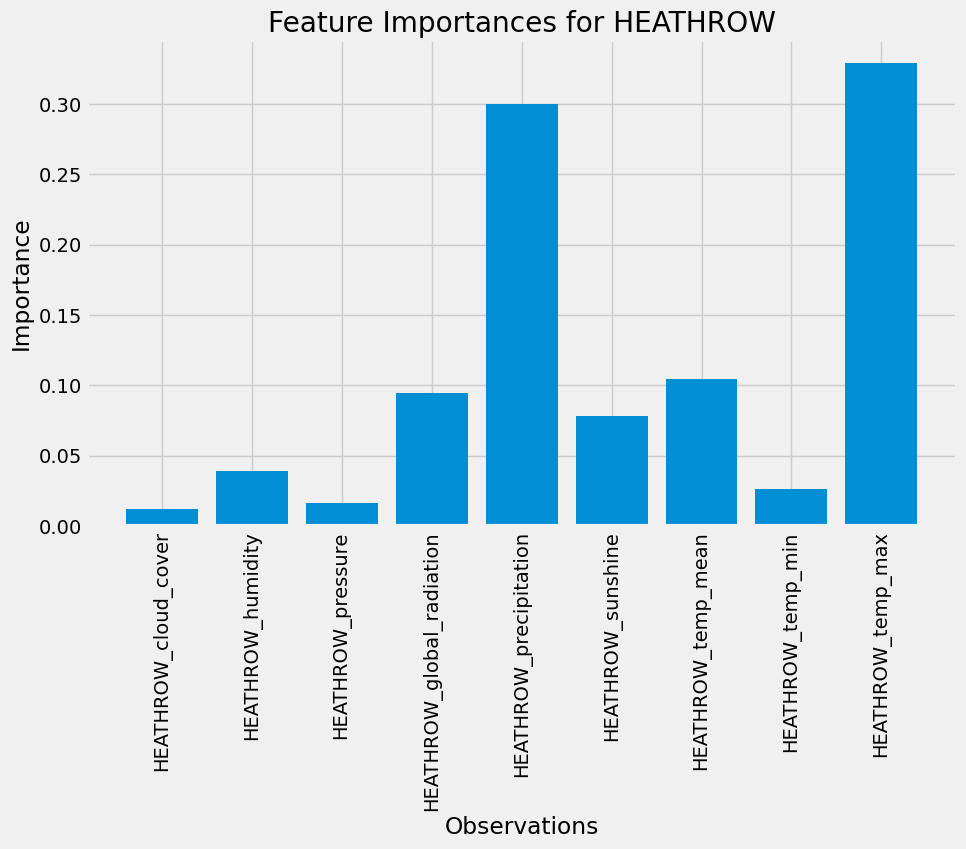

In [50]:
plt.style.use('fivethirtyeight')
# Graph the importance of the observations for each top station
for station_name, subset in subsets.items():
    importances_station = clf_station.feature_importances_
    plt.figure(figsize=(10, 6))
    plt.bar(subset.columns, importances_station)
    plt.xlabel('Observations')
    plt.ylabel('Importance')
    plt.title(f'Feature Importances for {station_name}')
    plt.xticks(rotation=90)
    plt.savefig(f'feature_importances_{station_name}.png')
    plt.show()


The Random Forest algorithm is very well performing on all stations for a span of 10 years (accuracy: 80%) and is great at classifying the pleasant days for each individual station on the whole period (accuracy: 100%)